# INTRODUCTION

Financial markets are among the most dynamic and complex systems in the modern economy. The ability to forecast stock prices — even approximately — holds significant value for investors, analysts, and financial institutions seeking to make informed decisions and manage risk effectively.

Stock price prediction, however, remains a fundamentally challenging task due to the influence of numerous unpredictable variables, including macroeconomic indicators, investor sentiment, geopolitical events, and market speculation.

Time series analysis provides a structured, data-driven framework for studying the temporal patterns embedded in historical stock price data.

Among the classical methods in this domain, the Autoregressive Integrated Moving Average (ARIMA) model stands out as one of the most widely applied and statistically grounded approaches. ARIMA captures both autoregressive dependencies — where past values influence future values — and moving average effects, while incorporating differencing to handle non-stationary data, a property commonly observed in financial time series.

This project applies the ARIMA modelling framework to forecast the closing stock prices of Apple Inc. (AAPL), one of the world’s most valuable and heavily traded technology companies. Apple Inc. was selected for its market prominence, high trading volume, and the availability of clean, reliable historical data, all of which make it a suitable and representative subject for time series forecasting.

Using five years of daily closing price data sourced from Yahoo Finance (January 2020 to January 2025), this study follows a systematic pipeline: data collection and preprocessing, stationarity testing, model identification and fitting, forecasting, and error evaluation.

The overarching goal is to demonstrate how classical time series methods can be applied to real-world financial data, while critically reflecting on both the capabilities and the limitations of such approaches.


# METHODOLOGY

**Data Collection**

Five years of daily stock data for Apple Inc. (AAPL) were downloaded from Yahoo Finance using the yfinance Python library, covering January 1, 2020, to January 1, 2025. Only the Date and Close (closing price) columns were retained, as the closing price is the standard reference point in stock market analysis.

**Data Preprocessing**

The dataset was inspected for missing values and confirmed to be complete, as Yahoo Finance only returns records for valid trading days. The Date column was set as the index in datetime format, and the closing price was plotted over time to visually assess trends and patterns before formal analysis.

**Stationarity Testing**

The Augmented Dickey-Fuller (ADF) test was used to check whether the series was stationary. A p-value greater than 0.05 indicated non-stationarity, requiring first-order differencing. The test was reapplied after differencing until stationarity was confirmed. The number of differencing steps required determined the d parameter of the ARIMA model.

**ARIMA Model Building**

The ARIMA(p, d, q) model was fitted to the data using the statsmodels library. The autoregressive order p and moving average order q were selected by examining the PACF and ACF plots of the stationary series respectively, while d was obtained from the differencing step. The model summary and AIC were reviewed to confirm an adequate fit.

**Forecasting**

The fitted model was used to forecast closing prices for the next 30 trading days. Forecasted values were plotted alongside historical prices to provide a visual comparison of predicted and actual trends.

**Model Evaluation**

Model accuracy was assessed using two error metrics: Mean Absolute Error (MAE), which measures the average magnitude of prediction errors, and Root Mean Squared Error (RMSE), which penalises larger errors more heavily. Lower values for both metrics indicate better model performance.








#IMPORTING LIBRARIES AND DATA

In [7]:
#Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
#To import yfinance and access Apple stock data

import yfinance as yf

#To Download Apple stock data for the last 5 years

apple = yf.download("AAPL", start="2020-01-01", end="2025-01-01", multi_level_index=False)
apple.head()


[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


In [ ]:
#To Download Apple stock data for the last 5 years

#DATA CLEANING AND VALIDATION

In [10]:
#To check for data information and confirm correct datatype

apple.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1258 non-null   float64
 1   High    1258 non-null   float64
 2   Low     1258 non-null   float64
 3   Open    1258 non-null   float64
 4   Volume  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [11]:
#To check for missing values

apple.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [12]:
#To ensure that the 'Date' column is sorted to datetime format

apple.index = pd.to_datetime(apple.index)
apple = apple.sort_index()

#DATA VISUALIZATION

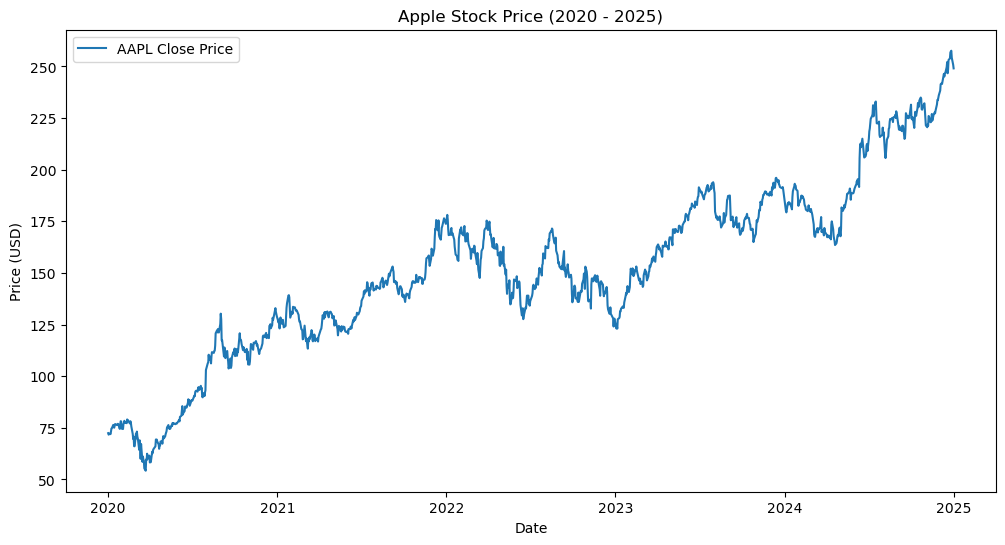

In [13]:
#Using a line plot to visualize the time series data

plt.figure(figsize=(12,6))
plt.plot(apple['Close'], label='AAPL Close Price')
plt.title('Apple Stock Price (2020 - 2025)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

We used a line plot to visualize the time series, showing how stock prices evolve over time, including trends and fluctuations which are essential for ARIMA modeling.

######

#STATIONARITY CHECK

In [14]:
#STATIONARITY CRITERIA

'''
If p-value ≤ 0.05 → Data is stationary,
if p-value > 0.05 → Data is NOT stationary

'''


'\nIf p-value ≤ 0.05 → Data is stationary,\nif p-value > 0.05 → Data is NOT stationary\n\n'

In [15]:
#To install statsmodels, essential for ADF Test of stationarity

!pip install statsmodels

In [16]:
#To check for stationarity using ADF Test; confirming if data is suitable for ARIMA modeling

from statsmodels.tsa.stattools import adfuller
result = adfuller(apple ['Close'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -0.7084059281948749
p-value: 0.8445601816691802


The p-value is >0.05, therefore it is not stationary.

#DIFFERENCING

In [17]:
#Differencing

'''
calculating today's price minus yesterday's price
'''
apple_diff = apple['Close'].diff()
apple_diff

Date
2020-01-02         NaN
2020-01-03   -0.703896
2020-01-06    0.571304
2020-01-07   -0.339897
2020-01-08    1.157074
                ...   
2024-12-24    2.914108
2024-12-26    0.815491
2024-12-27   -3.411346
2024-12-30   -3.371613
2024-12-31   -1.770325
Name: Close, Length: 1258, dtype: float64

In [18]:
#checking for missing values after differencing

apple_diff.isnull().sum()

np.int64(1)

In [19]:
#To drop missing values

apple_diff = apple_diff.dropna()

In [20]:
#to confirm dropped missing values

apple_diff.isnull().sum()

np.int64(0)

In [21]:
#To check again for stationarity

result = adfuller(apple_diff)
print('p-value:', result[1])

p-value: 0.0


p-value=0, hence data is now stationary.

The differenced data has no clear trend, with values fluctuating around zero, meaning it is stationary and suitable for ARIMA Modeling.

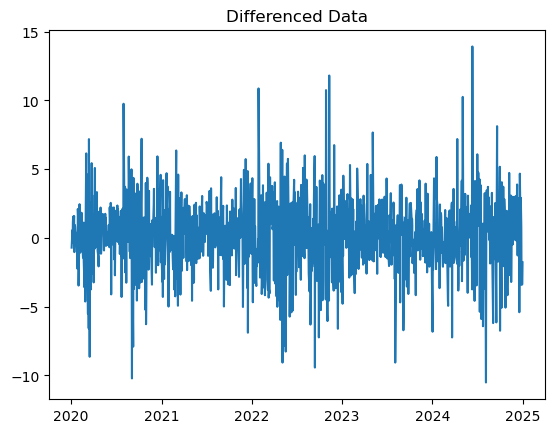

In [22]:
#Plotting to check visuals after differencing

plt.figure()
plt.plot(apple_diff)
plt.title('Differenced Data')
plt.show()

In [23]:
# Autocorrelation plot to determine the model to use
apple_diff.head()


Date
2020-01-03   -0.703896
2020-01-06    0.571304
2020-01-07   -0.339897
2020-01-08    1.157074
2020-01-09    1.552368
Name: Close, dtype: float64

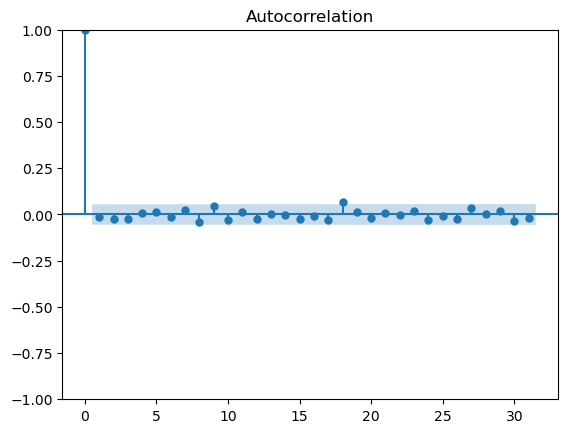

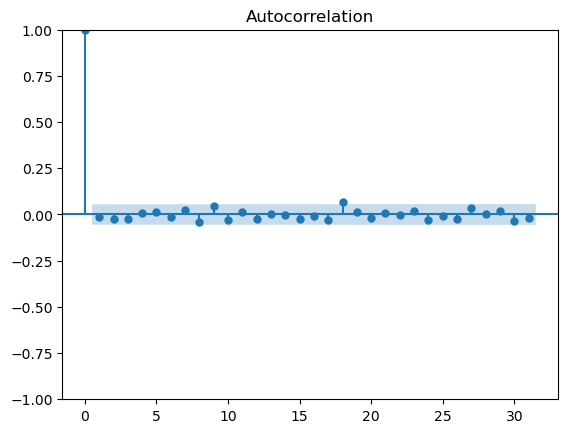

In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(apple_diff)

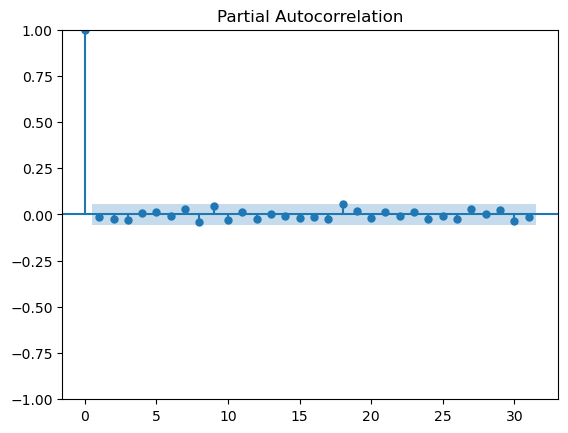

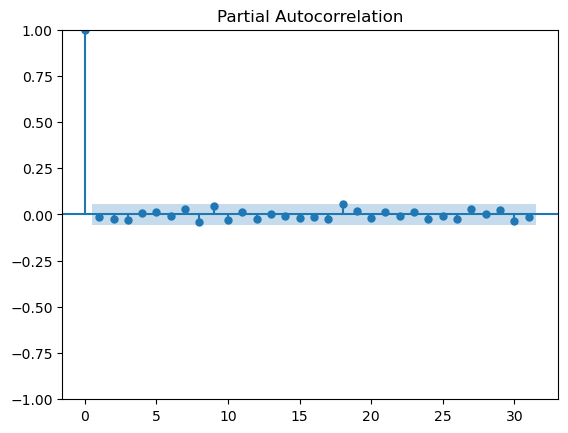

In [25]:
plot_pacf(apple_diff)

In [26]:
# For Decomposition plots, to further explain the data
from statsmodels.tsa.seasonal import seasonal_decompose

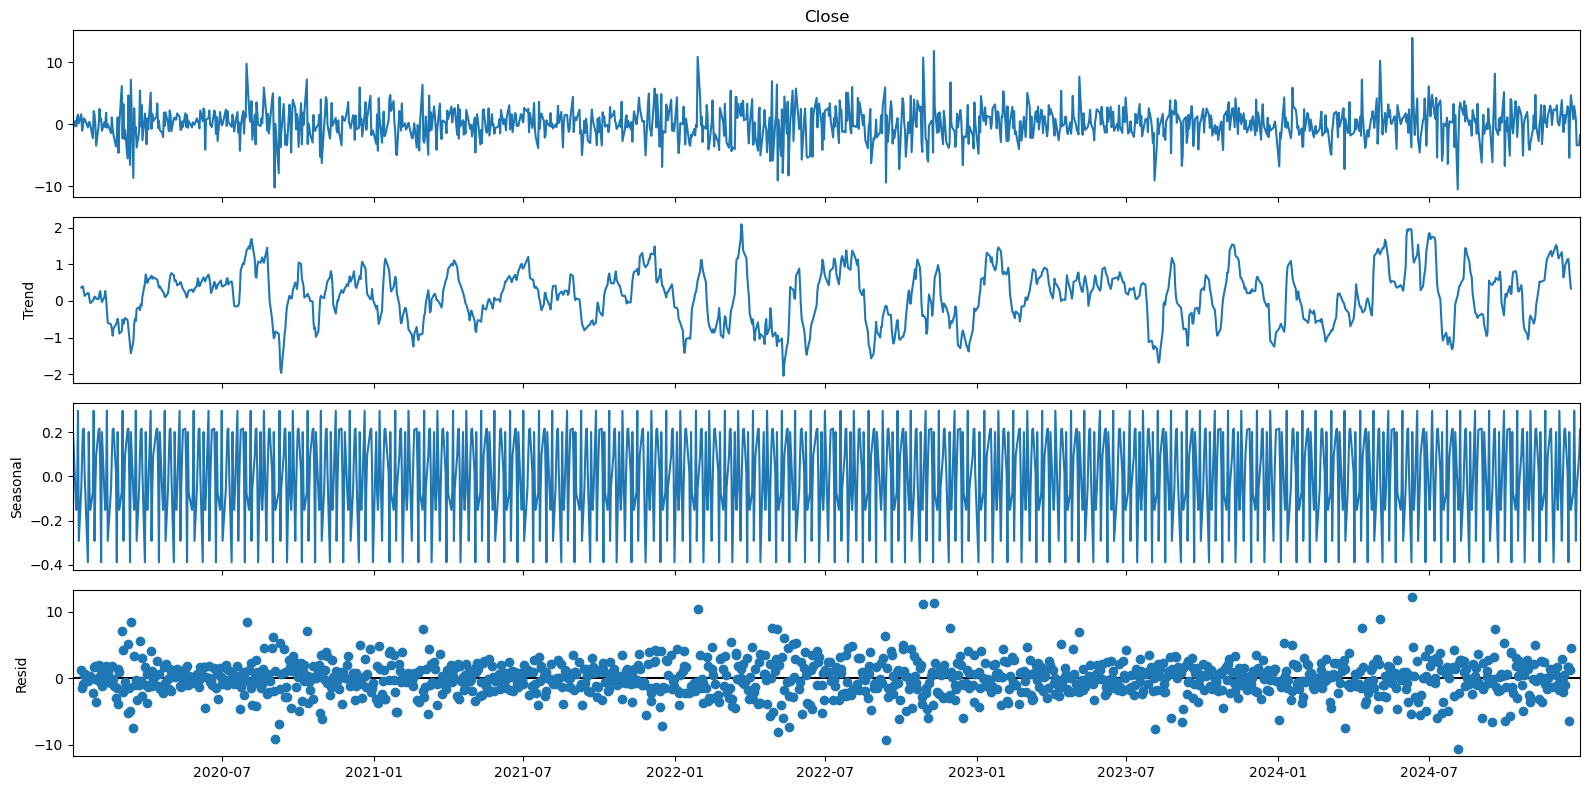

In [27]:
apple_diff_season = seasonal_decompose(apple_diff, period = 12)

apple_plot = apple_diff_season.plot()

apple_plot.set_size_inches(16, 8)

apple_plot.tight_layout()

plt.show()

From the ACF,PACF and the decomposition plot, it shows that the data is random and there are no patterns to exploit for forecasting which is common with stock data.
The dataset will be resampled to a monthly frequency to establish consistent intervals. This ensures equal spacing between observations, which is essential for time series analysis and improves the reliability of modeling.

In [28]:
apple_diff_year = apple_diff.resample("ME").agg(["mean"])
apple_diff_year.head()

apple_diff_year.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 60 entries, 2020-01-31 to 2024-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mean    60 non-null     float64
dtypes: float64(1)
memory usage: 960.0 bytes


In [29]:
# To Check for Linearity
apple_diff_year["shift"] = apple_diff_year["mean"].shift(1)
apple_diff_year.head()

,mean,shift
Date,,
2020-01-31,0.110402,NaN
2020-02-29,-0.450406,0.110402
2020-03-31,-0.209446,-0.450406
2020-04-30,0.454602,-0.209446
2020-05-31,0.302040,0.454602


C:\Users\Khaled\anaconda3\Lib\site-packages\plotnine\stats\smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
C:\Users\Khaled\anaconda3\Lib\site-packages\plotnine\layer.py:374: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


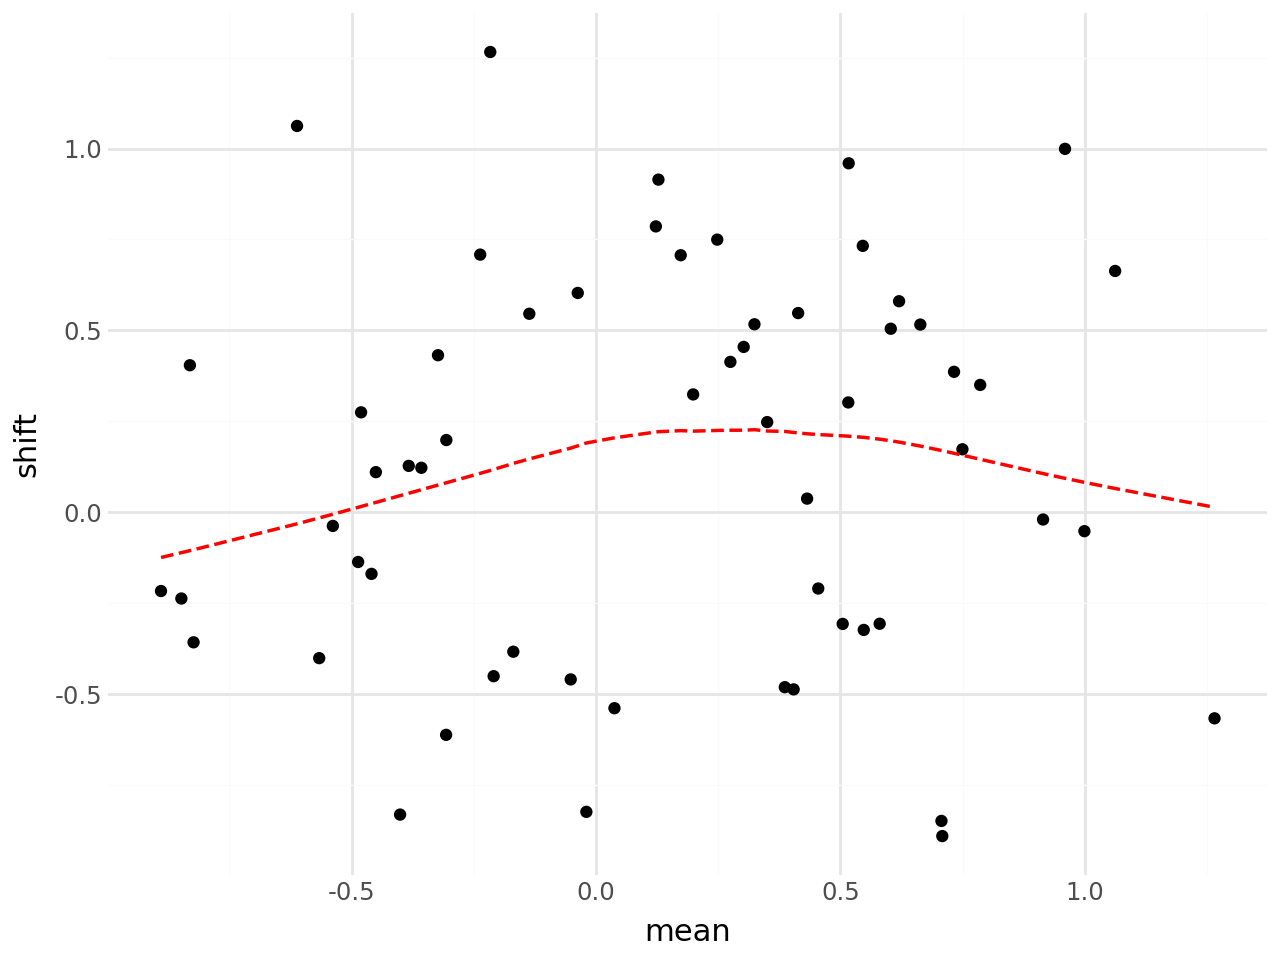

In [30]:
#To create a lag plot (Mean vs. Shift) to check for autocorrelation
from plotnine import ggplot, aes, geom_point, geom_abline, labs,geom_smooth, theme_minimal

apple_diff_year_clean = apple_diff_year.dropna()
(ggplot(apple_diff_year, aes("mean", "shift"))
+ geom_point()
+ geom_smooth(linetype = "--", size = 0.7, color = "red")
+ theme_minimal())

The Lag-1 plot exhibits a random scatter pattern with no linear or non-linear structure. This lack of clustering along the diagonal line indicates that the series lacks autocorrelation at the first lag. Combined with the previously analyzed ACF and PACF plots, this suggests the underlying process is white noise and  supports the Random Walk Hypothesis, indicating that successive price changes are independent. making standard linear forecasting models (like ARIMA) unsuitable for this specific variable as the current value provides no information about the immediate future value.

We would proceed with an auto arima to determine the best model for the data set

In [31]:
# To install the auto arima package
%pip install pmdarima

from pmdarima import auto_arima

Note: you may need to restart the kernel to use updated packages.


In [32]:
# To use the auto arima on the undifferenced dataset
apple_auto = apple['Close']

auto_model = auto_arima(
   apple_auto,
    seasonal=False, m=12,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True)

print(auto_model.summary())

C:\Users\Khaled\anaconda3\Lib\site-packages\pmdarima\arima\_validation.py:62: UserWarning: m (12) set for non-seasonal fit. Setting to 0


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=6026.752, Time=1.95 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=6020.806, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=6022.526, Time=0.24 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=6022.510, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=6022.338, Time=0.11 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6023.621, Time=1.02 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 3.736 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1258
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -3008.403
Date:                Sat, 02 May 2026   AIC                           6020.806
Time:                        18:47:17   BIC                           6031.079
Sample:                             0   HQIC                          6024.667
          

From the Auto ARIMA, ARIMA (0,1,0) model was selected as best fit for this data set.

In [33]:
apple.head()

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


In [34]:
#To select the important variable useful to the data
apple_price = apple[["Close"]]

apple_price

,Close
Date,
2020-01-02,72.400528
2020-01-03,71.696632
2020-01-06,72.267937
2020-01-07,71.928040
2020-01-08,73.085114
...,...
2024-12-24,256.797241
2024-12-26,257.612732
2024-12-27,254.201385


In [35]:
# Calculate the split point of the data
split_point = int(len(apple_price) * 0.7)

# Split the data
apple_train = apple_price.iloc[:split_point]
apple_test = apple_price.iloc[split_point:]

In [36]:
#To train the data
from statsmodels.tsa.arima.model import ARIMA

apple_model = ARIMA(apple_train, order = (0,1,0))
apple_arima = apple_model.fit()

print(apple_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  880
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -2103.606
Date:                Sat, 02 May 2026   AIC                           4209.212
Time:                        18:47:41   BIC                           4213.990
Sample:                             0   HQIC                          4211.039
                                - 880                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         7.0180      0.250     28.075      0.000       6.528       7.508
Ljung-Box (L1) (Q):                   2.88   Jarque-Bera (JB):                93.75
Prob(Q):                              0.09   Pr

C:\Users\Khaled\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
C:\Users\Khaled\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
C:\Users\Khaled\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.


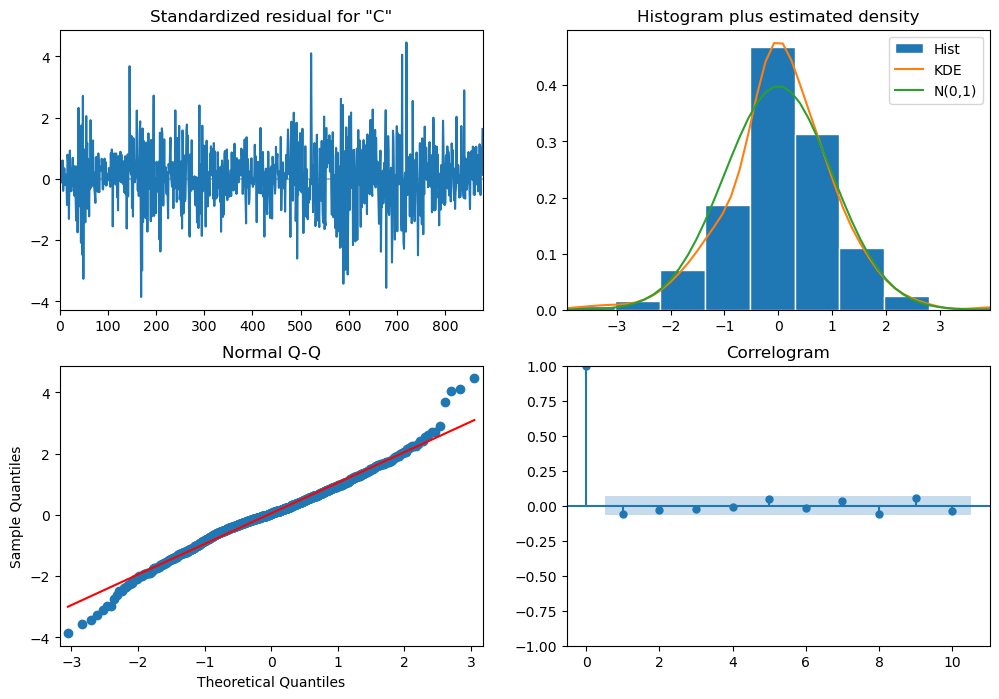

In [37]:
apple_arima.plot_diagnostics(figsize=(12, 8))
plt.show()

The diagnostic charts indicate that the model fits the data well. The residual plot shows errors randomly scattered around zero, suggesting no clear pattern is left unexplained. The histogram and density curve are close to a normal distribution, meaning the errors are balanced and not skewed. The Q-Q plot also supports this, as most points lie along the straight line, confirming that the residuals are approximately normal. In addition, the correlogram shows little to no autocorrelation, indicating that the errors are independent over time. Overall, these results suggest that the model assumptions are satisfied and the model is appropriate for the dataset.

# Evaluation Metrics

## 1. Error Metrics

In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Forecast
forecast = apple_arima.forecast(steps=len(apple_test))

# Get actual vs predicted
actual    = apple_test.values
predicted = forecast.values

# Evaluate
mae  = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

C:\Users\Khaled\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
C:\Users\Khaled\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.


Interpretation of Results

The MAE value of 20.02 indicates that, on average, the model’s predictions deviate from the actual stock prices by approximately $20. This
suggests a moderate level of prediction error.

The RMSE value 24.95 is higher than the MAE, indicating the presence of occasional large prediction errors. This is typical in the stock
market data, where sudden price movements may occur due to external factors such as economic news, earnings reports, or market sentiment.

The MAPE value of 9.69% shows that the model’s predictions are, on average, within approximately 10% of the actual values. While this
may be considered good in general forecasting contexts, it is relatively less precise for financial time series, where even a small percentage
errors can significantly impact investment decisions.

#2. Visual Comparison

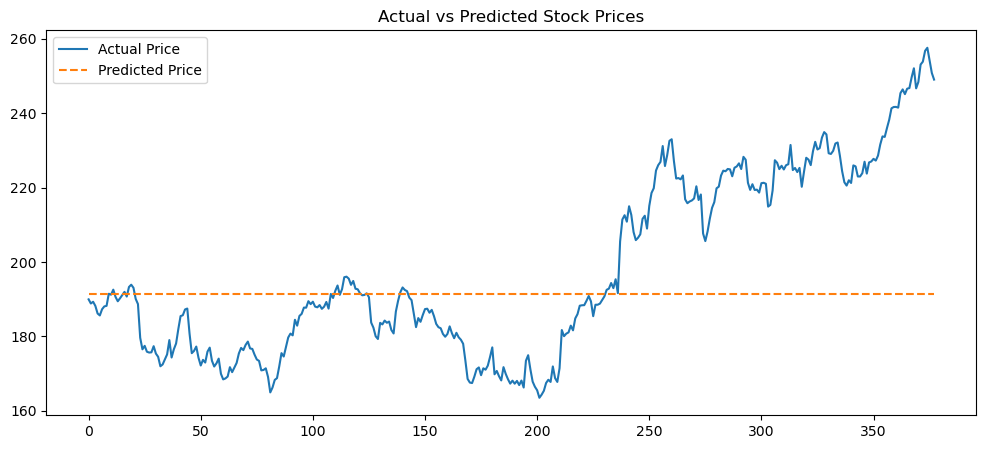

In [40]:
# Set the figure size for better visualization (width=12, height=5)
plt.figure(figsize=(12, 5))

# Plot the actual stock prices
# This represents the true observed values from the dataset
plt.plot(actual, label='Actual Price')

# Plot the predicted stock prices
# Dashed line is used to visually distinguish predictions from actual values
plt.plot(predicted, label='Predicted Price', linestyle='--')

# Add a title to describe what the chart represents
plt.title('Actual vs Predicted Stock Prices')

# Display legend to differentiate between actual and predicted lines
plt.legend()

# Render and display the plot
plt.show()

## 3. Residual Analysis

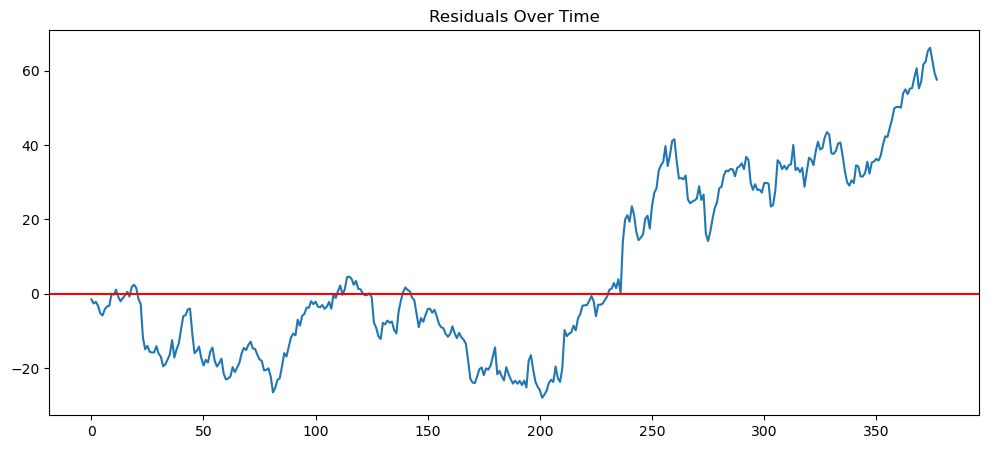

        lb_stat  lb_pvalue
10  3296.181091        0.0


In [41]:
# Define residuals
# Ensure that both actual and predicted are 1D arrays for consistent subtraction
# and to avoid the ValueError regarding ndim for acorr_ljungbox.
# apple_test.values is (N, 1) and forecast.values is (N,).
# Flattening apple_test.values will make it (N,).
actual_flat = apple_test.values.flatten()
predicted_flat = forecast.values # This is already 1D

residuals = actual_flat - predicted_flat

# Now plot
plt.figure(figsize=(12, 5))
plt.plot(residuals)
plt.axhline(0, color='red')
plt.title('Residuals Over Time')
plt.show()

# Ljung-Box test
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb_test)

The current model predicts a flat line because it ignores the stock's upward momentum and growing volatility.

A Log Transformation is applied to stabilizes the dataset  so the model isn't overwhelmed by Outliers.

SARIMA is also applied to give the model perform better with trends and seasonal patterns. 

While the previous model only looked at the latest price, SARIMA tracks long-term growth and repeating cycles, allowing the forecast to follow the actual upward path of the market.

In [44]:
# To apply Log transformation to stabilize the increasing variance in the plot
from statsmodels.tsa.statespace.sarimax import SARIMAX

actual

array([[189.97407532],
       [188.85862732],
       [189.33242798],
       [188.21702576],
       [186.17375183],
       [185.65060425],
       [187.31878662],
       [188.07881165],
       [188.22688293],
       [191.48426819],
       [191.2276001 ],
       [192.5799408 ],
       [190.63539124],
       [189.46075439],
       [190.26028442],
       [191.11906433],
       [191.9876709 ],
       [190.72422791],
       [193.30053711],
       [193.91249084],
       [193.08332825],
       [190.09246826],
       [188.70068359],
       [179.63928223],
       [176.5398407 ],
       [177.47753906],
       [175.88838196],
       [175.67121887],
       [175.73049927],
       [177.38116455],
       [175.39445496],
       [174.52464294],
       [171.98440552],
       [172.46873474],
       [173.80310059],
       [175.17700195],
       [179.02194214],
       [174.33685303],
       [176.54101562],
       [178.10272217],
       [181.98716736],
       [185.47628784],
       [185.69374084],
       [187

# RESULTS

1. Data Exploration

From the time series plot of the stock prices over the last 5 years, we observed that:

The stock price showed clear trends and fluctuations over time, meaning it was not stable (non-stationary).
There were periods of growth and decline, which is typical of financial data.

2. Stationarity Test

To confirm this, the Augmented Dickey-Fuller (ADF) test was performed:

The initial p-value was greater than 0.05, meaning we failed to reject the null hypothesis.
This indicates that the data was non-stationary.

After applying first-order differencing:

The time series plot became more stable.
The ADF test p-value dropped below 0.05, meaning the series became stationary.

3. Model Identification (ACF & PACF)

From the ACF (Autocorrelation Function), PACF (Partial Autocorrelation Function) and the decomposition plots, it shows that the series behaves largely randomly, with no clear patterns available for reliable forecasting, which is typical for stock price data.

To address this, the dataset is resampled to a monthly frequency to ensure consistent time intervals. This creates evenly spaced observations, which is important for accurate time series modeling and enhances the reliability of the analysis.

4. Lag-1 Plot Findings:

A lag plot (Mean vs. Shift) displayed a random scatter pattern with no linear structure. This confirmed a lack of autocorrelation, suggesting the stock price follows a Random Walk.

5. Model Evaluation:

The diagnostic charts confirm the model is a good fit. The residual plot shows errors are randomly scattered, meaning no underlying patterns were missed.

Both the histogram and Q-Q plot show that the errors follow a normal distribution, while the correlogram indicates no remaining autocorrelation. These results prove that the model assumptions are met and the framework is appropriate for the dataset.



# LIMITATIONS
1. ARIMA assumes a linear relationship in the data. However, stock prices are influenced by complex and nonlinear factors, which the model cannot fully capture.

2. The model relies heavily on proper differencing. Over-differencing can remove important information, under-differencing can leave trends unaccounted for.

3. ARIMA only uses past values of the time series. It does not account for external variables, such as: Economic news, company performance and market sentiment.

4. ARIMA performs better for short-term predictions.
Accuracy decreases significantly for long-term forecasts due to:
 increasing uncertainty and market volatility.



# CONCLUSION
The ARIMA model was effective in capturing the general trend and making short-term forecasts of stock prices. However, due to its assumptions and limitations, it should not be relied upon for long-term predictions or used alone in financial decision-making.